# **Forecasting System for Safety Stock in the Oil and Gas Industry**

### **Introduction**

The goal of this part of the project is to develop a forecasting system for safety stock management in the oil and gas industry.
The system aims to optimize inventory levels, ensure supply chain resilience, and enhance operational efficiency by accurately predicting demand, monitoring tank behavior, and detecting anomalies.

### **Data Sources:**

**ORDERS.xlsx:** Contains information about orders, including order ID, customer details, status, timestamps, and related attributes.

**ORDERS2.xlsx:** Similar to ORDERS.xlsx, with additional order details and timestamps.

**ORDERS_TANK_INV.xlsx:** Provides data on tank inventory associated with orders, including tank code, inventory quantities, and related metrics.

**ORDERS_TANK_INV2.xlsx:** Similar to ORDERS_TANK_INV.xlsx, with additional inventory quantity types and metrics.

**TANK1.xlsx:** Contains detailed information about tanks, including tank code, compartment details, product information, capacity, and operational settings.

### **Data Exploration & Pre-Processing**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df_orders = pd.read_excel("Orders.xlsx")
df_orders2 = pd.read_excel("Orders2.xlsx")
df_order_tank_inv = pd.read_excel("ORDERS_TANK_INV.xlsx")
df_order_tank_inv2 = pd.read_excel("ORDERS_TANK_INV2.xlsx")
df_tank1 = pd.read_excel("TANK1.xlsx")

In [3]:
df_orders.head(10)

,Unnamed: 0,ORDER_ID,LOADED_DRIVER_NUMBER,CARRIER_NUMBER,TRACTOR_CARRIER_NUMBER,LOADED_CARRIER_NUMBER,FOLIO_NUMBER,TRACTOR_NUMBER,SUPPLIER_NUMBER,CUSTOMER_NUMBER,...,VALIDATING_NODE_NAME,PETROEX_COMPANY_CODE,ELVIS_AUTHORIZED,OVERRIDE_TOLERANCE_CHECKS,AIC_STATUS,BLEND_TOLERANCE_STATUS,ADDITIVE_TOLERANCE_STATUS,AUTHORIZATION_REQUEST_ID,TABS_ORDER_NUMBER,PREV_ORDER_ID
0,0,8320,158,1,1.0,1,20210927.0,158.0,12,12,...,2,1,2,1,2,2,2,2,150,8320
1,1,12128,6,1,1.0,1,20210928.0,6.0,13,13,...,2,1,2,1,2,2,2,2,235,12128
2,2,19110,105,1,1.0,1,20210928.0,105.0,12,12,...,2,1,2,1,2,2,2,2,388,19110
3,3,19143,171,1,1.0,1,20210928.0,171.0,12,12,...,2,1,2,1,2,2,2,2,389,19143
4,4,19176,149,1,1.0,1,20210927.0,149.0,6,6,...,2,1,2,1,2,2,2,2,390,19176
5,5,19209,68,1,1.0,1,20210928.0,68.0,8,8,...,2,1,2,1,2,2,2,2,391,19209
6,6,19265,185,1,1.0,1,20210927.0,185.0,8,8,...,2,1,2,2,2,2,2,2,392,19265
7,7,19374,149,1,1.0,1,NaN,149.0,6,6,...,2,2,2,1,2,0,2,2,0,19374
8,8,19386,200,1,1.0,1,20210927.0,200.0,1,3,...,2,1,2,2,2,2,2,2,393,19386
9,9,19423,55,1,1.0,1,20210927.0,55.0,8,8,...,2,1,2,2,2,2,2,2,394,19423


In [4]:
df_order_tank_inv.head(10)

,Unnamed: 0,ORDER_ID,TANK_CODE,SEQUENCE_NUMBER,TERMINAL_PRODUCT_NUMBER,SUPPLIER_NUMBER,INVENTORY_QTY,FRAC_INVENTORY_QTY,GROSS_QUANTITY,GROSS_FRAC_QUANTITY,NET_QUANTITY,NET_FRAC_QUANTITY,WEIGHT,FRAC_WEIGHT,WEIGHT_IN_VAC,FRAC_WEIGHT_IN_VAC
0,0,8320,NaN,19683,7,12,0,0,0,0,0,0,0,0,0,0
1,1,8320,TK-205,19684,7,12,664,0,672,0,664,0,548,0,548,0
2,2,12128,NaN,24408,4,13,0,0,0,0,0,0,0,0,0,0
3,3,12128,NaN,24409,7,13,0,0,0,0,0,0,0,0,0,0
4,4,19110,NaN,22508,7,12,0,0,0,0,0,0,0,0,0,0
5,5,19110,TK-205,22509,7,12,21784,0,21988,0,21784,0,17969,0,17994,0
6,6,19143,TK-106,24415,4,12,3953,0,3990,0,3953,0,2905,0,2909,0
7,7,19143,TK-205,24416,7,12,25750,0,25989,0,25750,0,21240,0,21269,0
8,8,19176,NaN,19360,7,6,0,0,0,0,0,0,0,0,0,0
9,9,19176,TK-205,19361,7,6,27733,0,27994,0,27733,0,22877,0,22908,0


In [5]:
df_tank1.head(3)

,TANK_CODE,NAME,COMPARTMENT_OWNER_ID,MAJORITY_SHAREHOLDER,COMPARTMENT_CONTAINER_CODE,RT_GROSS_QUANTITY,COMPARTMENT_CONTAINER_TYPE,TERMINAL_PRODUCT_NUMBER,COMPARTMENT_NUMBER,RT_NET_QUANTITY,...,RT_TOV_ORIGIN,RT_TEMPERATURE_ORIGIN,RT_DENSITY_ORIGIN,RT_NSV_ORIGIN,RT_VAPOR_TEMPERATURE_ORIGIN,RT_PRESSURE_ORIGIN,RT_FREE_WATER_LEVEL_ORIGIN,RT_WATER_QUANTITY_ORIGIN,AUTO_PRODUCT_LEVEL_UNIT,AUTO_FREE_WATER_LEVEL_UNIT
0,TK-100,ADD GO AFR,NaN,NaN,NaN,2500,NaN,8,NaN,2494,...,4,3,3,4,3,3,3,4,0,0
1,TK-101,GASOIL,NaN,NaN,NaN,3082788,NaN,7,NaN,3076743,...,4,1,3,4,3,3,3,4,2,2
2,TK-102,GASOIL,NaN,NaN,NaN,2646488,NaN,7,NaN,2642783,...,4,1,3,4,3,3,3,4,2,2


In [6]:
# Select necessary columns for orders datasets
orders_columns = ['ORDER_ID', 'STATUS_DATE']
df_orders_selected = pd.concat([df_orders[orders_columns], df_orders2[orders_columns]], ignore_index=True)

In [7]:
df_orders_selected.head(10)

/usr/local/lib/python3.10/dist-packages/google/colab/_dataframe_summarizer.py:102: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  pd.Series(non_null_values)


,ORDER_ID,STATUS_DATE
0,8320,2021-09-27 12:56:47.440000
1,12128,2021-09-28 10:08:35.607000
2,19110,2021-09-28 06:48:58.717000
3,19143,2021-09-28 10:09:11.093000
4,19176,2021-09-27 12:33:14.907000
5,19209,2021-09-28 10:08:05.390000
6,19265,2021-09-27 12:44:56.413000
7,19374,2021-09-27 12:33:47.283000
8,19386,2021-09-27 13:05:49.563000
9,19423,2021-09-27 13:08:29.597000


In [8]:
# Select necessary columns for orders tank inventory datasets
orders_tank_inv_columns = ['ORDER_ID', 'TANK_CODE', 'INVENTORY_QTY', 'NET_QUANTITY', 'GROSS_QUANTITY']
df_order_tank_inv_selected = pd.concat([df_order_tank_inv[orders_tank_inv_columns], df_order_tank_inv2[orders_tank_inv_columns]], ignore_index=True)

In [9]:
df_order_tank_inv_selected.head(10)

,ORDER_ID,TANK_CODE,INVENTORY_QTY,NET_QUANTITY,GROSS_QUANTITY
0,8320,NaN,0,0,0
1,8320,TK-205,664,664,672
2,12128,NaN,0,0,0
3,12128,NaN,0,0,0
4,19110,NaN,0,0,0
5,19110,TK-205,21784,21784,21988
6,19143,TK-106,3953,3953,3990
7,19143,TK-205,25750,25750,25989
8,19176,NaN,0,0,0
9,19176,TK-205,27733,27733,27994


In [10]:
# Select necessary columns from tank1
tank1_columns = ['TANK_CODE', 'NAME', 'RT_GROSS_QUANTITY', 'RT_NET_QUANTITY', 'RT_TEMPERATURE', 'RT_DENSITY', 'SHELL_CAPACITY', 'WORK_CAPACITY']
df_tank1_selected = df_tank1[tank1_columns]

In [11]:
df_tank1_selected.head(10)

,TANK_CODE,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,WORK_CAPACITY
0,TK-100,ADD GO AFR,2500,2494,18.0,830,5000,0
1,TK-101,GASOIL,3082788,3076743,17.6,820,40051040,0
2,TK-102,GASOIL,2646488,2642783,16.6,826,40052350,0
3,TK-103,GASOIL,37426008,37171857,22.9,826,40059210,0
4,TK-104,GASOIL,9709314,9686109,17.7,820,27029960,0
5,TK-105,MOGAS,6525230,6517139,16.0,733,9529820,0
6,TK-106,MOGAS,5289004,5273666,17.4,748,9533050,0
7,TK-200,ADD MOG AFR,2500,2493,18.0,800,5000,0
8,TK-201,MOGAS,7856289,7847647,15.9,741,14380470,0
9,TK-202,MOGAS,7684279,7662609,17.3,740,14384200,0


In [12]:
# Merge orders tank inventory datasets with tank1 dataset
saf_stock = pd.merge(df_order_tank_inv_selected, df_tank1_selected, on='TANK_CODE', how='inner')
# Merge with orders datasets
saf_stock = pd.merge(saf_stock, df_orders_selected, on='ORDER_ID', how='inner')


In [13]:
saf_stock.columns.tolist()

['ORDER_ID',
 'TANK_CODE',
 'INVENTORY_QTY',
 'NET_QUANTITY',
 'GROSS_QUANTITY',
 'NAME',
 'RT_GROSS_QUANTITY',
 'RT_NET_QUANTITY',
 'RT_TEMPERATURE',
 'RT_DENSITY',
 'SHELL_CAPACITY',
 'WORK_CAPACITY',
 'STATUS_DATE']

In [14]:
saf_stock.head(10)

,ORDER_ID,TANK_CODE,INVENTORY_QTY,NET_QUANTITY,GROSS_QUANTITY,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,WORK_CAPACITY,STATUS_DATE
0,8320,TK-205,664,664,672,GASOIL,13154914,13110054,18.9,821,27036170,0,2021-09-27 12:56:47.440000
1,19110,TK-205,21784,21784,21988,GASOIL,13154914,13110054,18.9,821,27036170,0,2021-09-28 06:48:58.717000
2,19143,TK-205,25750,25750,25989,GASOIL,13154914,13110054,18.9,821,27036170,0,2021-09-28 10:09:11.093000
3,19143,TK-106,3953,3953,3990,MOGAS,5289004,5273666,17.4,748,9533050,0,2021-09-28 10:09:11.093000
4,19176,TK-205,27733,27733,27994,GASOIL,13154914,13110054,18.9,821,27036170,0,2021-09-27 12:33:14.907000
5,19209,TK-205,29705,29705,29987,GASOIL,13154914,13110054,18.9,821,27036170,0,2021-09-28 10:08:05.390000
6,19209,TK-500,3,3,3,ADD GO TOTAL,2500,2493,18.0,800,5000,0,2021-09-28 10:08:05.390000
7,19265,TK-205,27730,27730,27993,GASOIL,13154914,13110054,18.9,821,27036170,0,2021-09-27 12:44:56.413000
8,19265,TK-106,4949,4949,4995,MOGAS,5289004,5273666,17.4,748,9533050,0,2021-09-27 12:44:56.413000
9,19265,TK-500,2,2,2,ADD GO TOTAL,2500,2493,18.0,800,5000,0,2021-09-27 12:44:56.413000


In [15]:
#checking for WORK_CAPACITY values
work_capacity_unique_count = saf_stock['WORK_CAPACITY'].nunique()
print("Number of unique values in WORK_CAPACITY column:", work_capacity_unique_count)

work_capacity_zero_count = (saf_stock['WORK_CAPACITY'] == 0).sum()
print("Number of occurrences of 0 in WORK_CAPACITY column:", work_capacity_zero_count)


Number of unique values in WORK_CAPACITY column: 2
Number of occurrences of 0 in WORK_CAPACITY column: 115021


In [16]:
# Drop the 'WORK_CAPACITY' column
saf_stock.drop(columns=['WORK_CAPACITY'], inplace=True)


In [17]:
# Create a boolean mask to identify rows where the values in "INVENTORY_QTY" and "NET_QUANTITY" are the same
same_values_mask = saf_stock['INVENTORY_QTY'] == saf_stock['NET_QUANTITY']

# Count the number of rows where the values in both columns are the same
same_values_count = same_values_mask.sum()

print("Number of rows where INVENTORY_QTY and NET_QUANTITY have the same values:", same_values_count)


Number of rows where INVENTORY_QTY and NET_QUANTITY have the same values: 115022


In [18]:
# Drop the 'INVENTORY_QTY' column
saf_stock.drop(columns=['INVENTORY_QTY'], inplace=True)


In [19]:
saf_stock.tail()

,ORDER_ID,TANK_CODE,NET_QUANTITY,GROSS_QUANTITY,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,STATUS_DATE
115019,3084976,TK-203,13850,13991,GASOIL,17986506,18010067,13.4,831,27044300,2023-07-17 21:26:00.617000000
115020,3085005,TK-203,13860,14002,GASOIL,17986506,18010067,13.4,831,27044300,2023-07-17 21:30:37.410000000
115021,3085159,TK-203,32667,32998,GASOIL,17986506,18010067,13.4,831,27044300,2023-07-17 21:46:10.407000000
115022,3085236,TK-203,32678,33009,GASOIL,17986506,18010067,13.4,831,27044300,2023-07-17 21:52:16.410000000
115023,3085283,TK-203,32658,32988,GASOIL,17986506,18010067,13.4,831,27044300,2023-07-17 22:15:43.377000000


In [20]:
saf_stock.shape

(115024, 11)

In [21]:
saf_stock.describe()

,ORDER_ID,NET_QUANTITY,GROSS_QUANTITY,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY
count,1.150240e+05,115024.000000,115024.000000,1.150240e+05,1.150240e+05,115024.000000,115024.000000,1.150240e+05
mean,1.482871e+06,15990.386085,16087.633311,9.198070e+06,9.162407e+06,18.213901,797.286697,1.832596e+07
std,8.940842e+05,13678.800960,13760.129982,8.928238e+06,8.873537e+06,1.564293,33.470123,1.324409e+07
min,8.320000e+03,0.000000,0.000000,2.500000e+03,2.493000e+03,13.400000,733.000000,5.000000e+03
25%,7.011185e+05,1983.000000,1996.000000,3.082788e+06,3.076743e+06,17.400000,748.000000,9.533050e+06
50%,1.421361e+06,13915.000000,13989.000000,7.684279e+06,7.662609e+06,18.000000,820.000000,2.702996e+07
75%,2.246340e+06,29861.000000,29989.000000,1.315491e+07,1.311005e+07,18.900000,821.000000,2.703617e+07
max,3.098887e+06,34974.000000,35005.000000,3.742601e+07,3.717186e+07,43.500000,1000.000000,4.020108e+07


In [22]:
saf_stock.dtypes

ORDER_ID               int64
TANK_CODE             object
NET_QUANTITY           int64
GROSS_QUANTITY         int64
NAME                  object
RT_GROSS_QUANTITY      int64
RT_NET_QUANTITY        int64
RT_TEMPERATURE       float64
RT_DENSITY             int64
SHELL_CAPACITY         int64
STATUS_DATE           object
dtype: object

**DESCRIPTION OF THE MERGED DATASET:**

1. `ORDER_ID`: Each order placed in the system is assigned a unique identifier. This column helps track and manage orders efficiently.

2. `TANK_CODE`: Tanks used for storing products are identified by unique codes. This column specifies the code associated with each tank, allowing easy identification and management.

3. `NET_QUANTITY`: This represents the net quantity of the product stored in the tank. Net quantity typically refers to the amount of product remaining after accounting for any deductions, such as losses or evaporation.

4. `GROSS_QUANTITY`: Gross quantity represents the total amount of product present in the tank without any deductions. It includes the net quantity along with any additional factors, such as losses or evaporation.

5. `NAME`: This column contains the name or type of product stored in the tank. It provides information about the nature of the product being handled, such as gasoline, diesel, or other petroleum products.

6. `RT_GROSS_QUANTITY`: Real-time gross quantity refers to the current or instantaneous total quantity of the product in the tank, as measured at the time of data recording. It provides up-to-date information about the tank's content.

7. `RT_NET_QUANTITY`: Similar to real-time gross quantity, real-time net quantity represents the current or instantaneous net quantity of the product in the tank, accounting for any deductions or losses. It reflects the actual amount of product available for use.

8. `RT_TEMPERATURE`: This column records the real-time temperature of the product in the tank. Temperature measurement is essential for certain products, as it can affect their properties and behavior.

9. `RT_DENSITY`: Real-time density represents the density of the product in the tank at the time of measurement. Density is a crucial parameter for many liquids, as it influences their weight, volume, and other properties.

10. `SHELL_CAPACITY`: Shell capacity refers to the maximum volume or capacity of the tank's shell. It indicates the total amount of product the tank can hold under normal operating conditions.

11. `STATUS_DATE`: This column records the date and time when the status of the tank, including various parameters like quantity, temperature, and density, was last updated or recorded. It provides a timestamp for the data entries, allowing for temporal analysis and tracking of changes over time.



*   **Missing Values:**




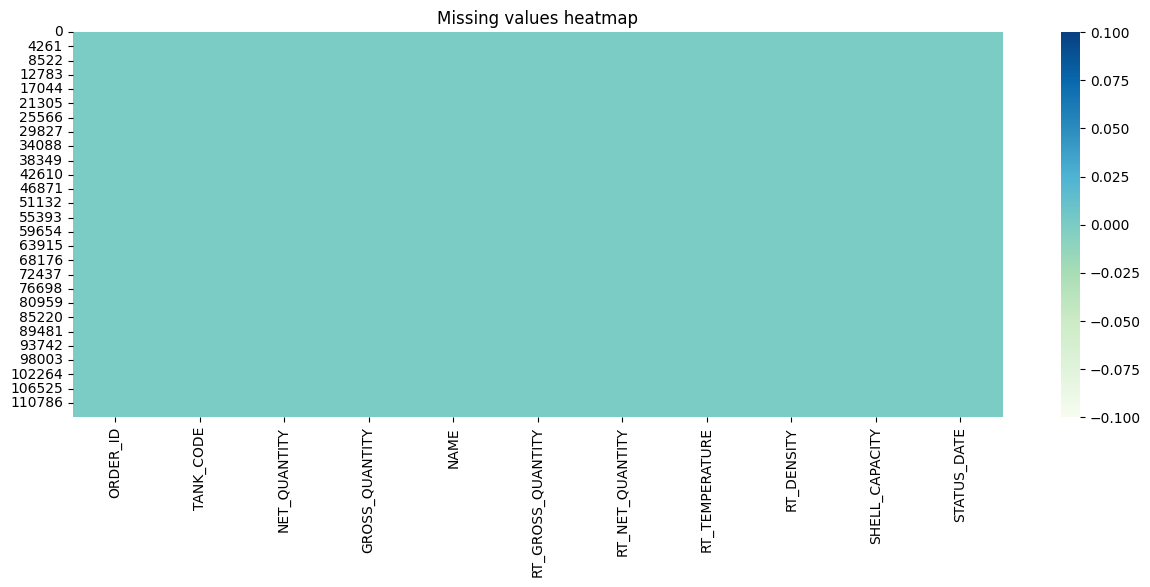

In [23]:
plt.figure(figsize=(15, 5))
sns.heatmap(data=saf_stock.isnull(),cbar=True, cmap="GnBu")
plt.title('Missing values heatmap')
plt.show()

In [24]:
# Count missing values per column
missing_values = saf_stock.isnull().sum()
print(missing_values)

# Calculate percentage of missing values
missing_percentage = missing_values / len(saf_stock) * 100
print(missing_percentage)


ORDER_ID             0
TANK_CODE            0
NET_QUANTITY         0
GROSS_QUANTITY       0
NAME                 0
RT_GROSS_QUANTITY    0
RT_NET_QUANTITY      0
RT_TEMPERATURE       0
RT_DENSITY           0
SHELL_CAPACITY       0
STATUS_DATE          0
dtype: int64
ORDER_ID             0.0
TANK_CODE            0.0
NET_QUANTITY         0.0
GROSS_QUANTITY       0.0
NAME                 0.0
RT_GROSS_QUANTITY    0.0
RT_NET_QUANTITY      0.0
RT_TEMPERATURE       0.0
RT_DENSITY           0.0
SHELL_CAPACITY       0.0
STATUS_DATE          0.0
dtype: float64




*   **Outliers:**




In [25]:
# Separate numerical and categorical columns
# Select numerical columns excluding 'ORDER_ID'
numerical_columns = saf_stock.select_dtypes(include=['int64', 'float64']).drop(columns=['ORDER_ID']).columns
categorical_columns = saf_stock.select_dtypes(include=['object']).columns

In [26]:
# Calculate the IQR for each numerical column
Q1 = saf_stock[numerical_columns].quantile(0.25)
Q3 = saf_stock[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Define a threshold to identify outliers
threshold = 1.5

# Identify outliers using the threshold
outliers_numerical = (saf_stock[numerical_columns] < (Q1 - threshold * IQR)) | (saf_stock[numerical_columns] > (Q3 + threshold * IQR))

# Display the number of outliers in each column
print("Number of outliers in each column:")
print(outliers_numerical.sum())



Number of outliers in each column:
NET_QUANTITY            0
GROSS_QUANTITY          0
RT_GROSS_QUANTITY    7204
RT_NET_QUANTITY      7204
RT_TEMPERATURE       9075
RT_DENSITY              3
SHELL_CAPACITY          0
dtype: int64


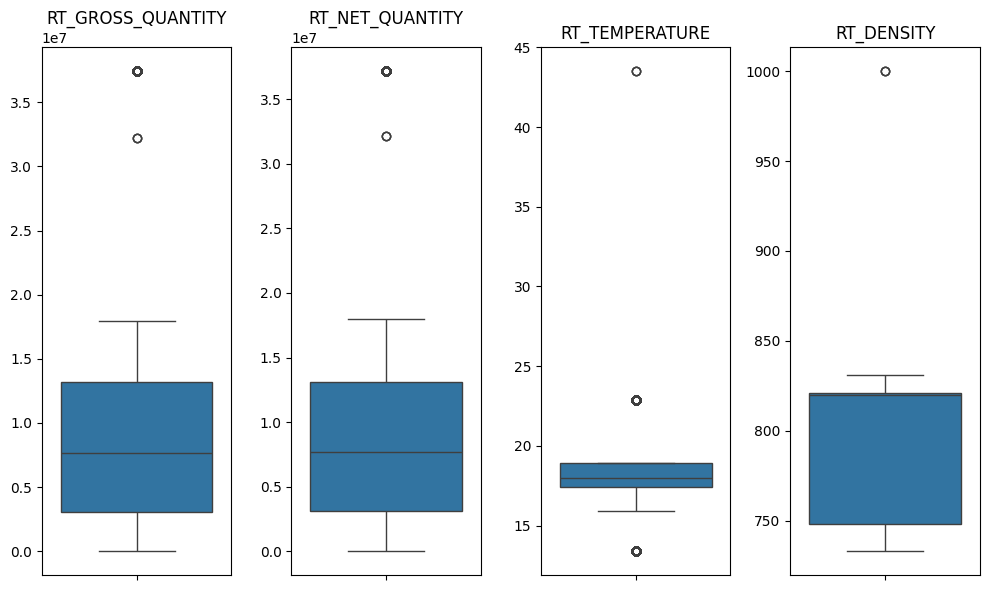

In [27]:
# Define the columns with outliers
outlier_columns = ['RT_GROSS_QUANTITY', 'RT_NET_QUANTITY', 'RT_TEMPERATURE', 'RT_DENSITY']

# Create box plots for each column with outliers
plt.figure(figsize=(10, 6))
for i, col in enumerate(outlier_columns, 1):
    plt.subplot(1, len(outlier_columns), i)
    sns.boxplot(y=saf_stock[col])
    plt.title(col)
    plt.ylabel('')
plt.tight_layout()
plt.show()


In [28]:
# Remove outliers from the original dataframe
saf_stock.drop(saf_stock[outliers_numerical.any(axis=1)].index, inplace=True)


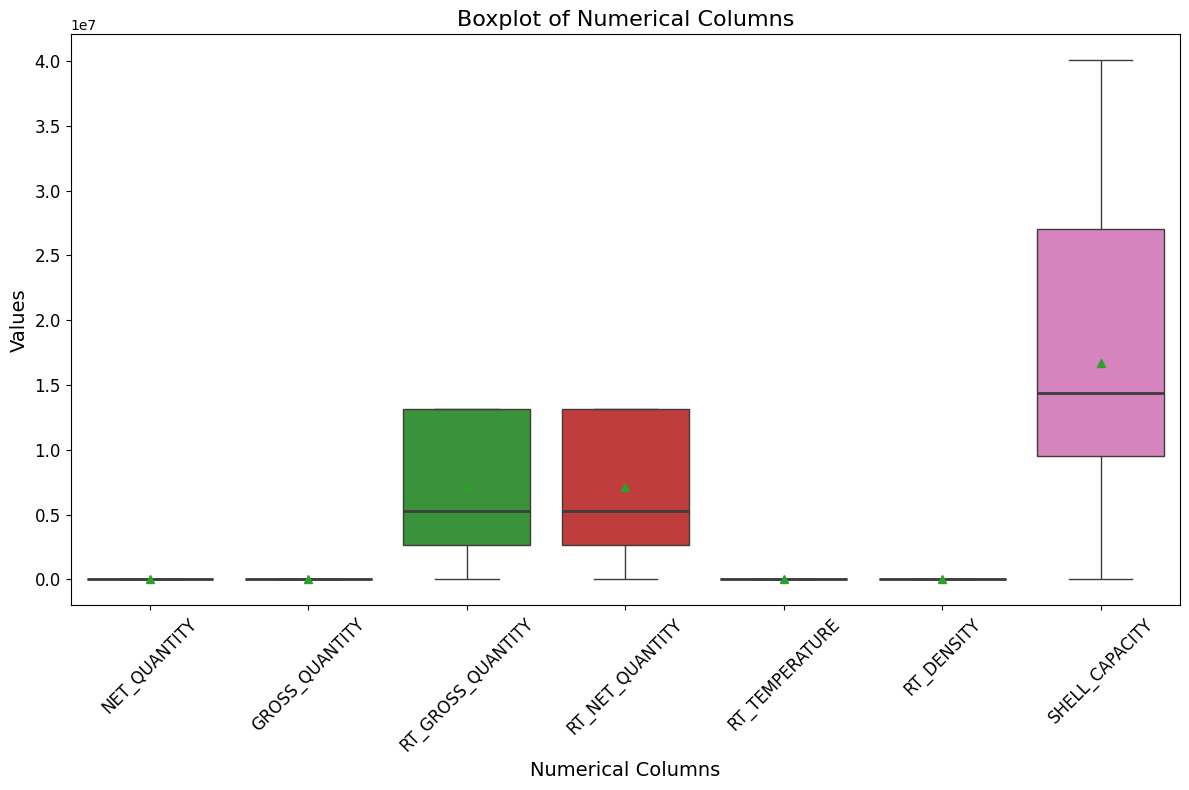

In [29]:
# Set up the figure size
plt.figure(figsize=(12, 8))

# Create the boxplot
sns.boxplot(
    data=saf_stock[numerical_columns],
    showmeans=True,
    medianprops={"linewidth": 2},
)

# Set labels and rotation for better readability
plt.xlabel("Numerical Columns", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add a title
plt.title("Boxplot of Numerical Columns", fontsize=16)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [30]:
import plotly.express as px

def plot_categorical_distribution(df, col):
    """
    Plots the distribution of categories in a categorical column using Plotly.

    Args:
        df (pandas.DataFrame): The DataFrame containing the data.
        col (str): The name of the categorical column.

    Returns:
        None
    """
    fig = px.histogram(df, x=col, title='Distribution of Categories in Column "{}"'.format(col))
    fig.update_layout(xaxis_title='Category', yaxis_title='Count', xaxis_tickangle=-45)
    fig.show()

# Apply the function for each categorical column
for col in categorical_columns:
    plot_categorical_distribution(saf_stock, col)


/usr/local/lib/python3.10/dist-packages/plotly/express/_core.py:1074: FutureWarning:

Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])



In [31]:
# Convert STATUS_DATE to datetime
saf_stock['STATUS_DATE'] = pd.to_datetime(saf_stock['STATUS_DATE'], errors='coerce')

# Count the number of invalid dates
invalid_date_count = saf_stock['STATUS_DATE'].isnull().sum()
print("Number of invalid dates:", invalid_date_count)

Number of invalid dates: 0


In [32]:
saf_stock.shape

(105949, 11)

In [33]:
saf_stock.head(20)

,ORDER_ID,TANK_CODE,NET_QUANTITY,GROSS_QUANTITY,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,STATUS_DATE
0,8320,TK-205,664,672,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:56:47.440
1,19110,TK-205,21784,21988,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 06:48:58.717
2,19143,TK-205,25750,25989,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 10:09:11.093
3,19143,TK-106,3953,3990,MOGAS,5289004,5273666,17.4,748,9533050,2021-09-28 10:09:11.093
4,19176,TK-205,27733,27994,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:33:14.907
5,19209,TK-205,29705,29987,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 10:08:05.390
6,19209,TK-500,3,3,ADD GO TOTAL,2500,2493,18.0,800,5000,2021-09-28 10:08:05.390
7,19265,TK-205,27730,27993,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:44:56.413
8,19265,TK-106,4949,4995,MOGAS,5289004,5273666,17.4,748,9533050,2021-09-27 12:44:56.413
9,19265,TK-500,2,2,ADD GO TOTAL,2500,2493,18.0,800,5000,2021-09-27 12:44:56.413


Correlation:

In [34]:
# Get the number of unique values and the unique values for each categorical column (excluding STATUS_DATE)
for col in categorical_columns:
    if col != 'STATUS_DATE':
        unique_values_count = saf_stock[col].nunique()
        unique_values = saf_stock[col].unique()
        print(f"Number of unique values in {col}: {unique_values_count}")
        print(f"Unique values in {col}: {unique_values}")


Number of unique values in TANK_CODE: 14
Unique values in TANK_CODE: ['TK-205' 'TK-106' 'TK-500' 'TK-600' 'TK-100' 'TK-300' 'TK-400' 'TK-200'
 'TK-105' 'TK-202' 'TK-201' 'TK-101' 'TK-104' 'TK-102']
Number of unique values in NAME: 8
Unique values in NAME: ['GASOIL' 'MOGAS' 'ADD GO TOTAL' 'ADD MOG TOTAL' 'ADD GO AFR' 'ADD GO OLA'
 'ADD MOG OLA' 'ADD MOG AFR']


**Encoding**

In [35]:
# Perform label encoding for TANK_CODE, NAME, and STATUS_DATE columns
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode TANK_CODE, NAME, and STATUS_DATE columns
saf_stock['TANK_CODE_encoded'] = label_encoder.fit_transform(saf_stock['TANK_CODE'])
saf_stock['NAME_encoded'] = label_encoder.fit_transform(saf_stock['NAME'])
saf_stock['STATUS_DATE_encoded'] = label_encoder.fit_transform(saf_stock['STATUS_DATE'])

# Create dictionaries to map encoded values to real values
tank_code_mapping = dict(zip(saf_stock['TANK_CODE_encoded'], saf_stock['TANK_CODE']))
name_mapping = dict(zip(saf_stock['NAME_encoded'], saf_stock['NAME']))
status_date_mapping = dict(zip(saf_stock['STATUS_DATE_encoded'], saf_stock['STATUS_DATE']))

# Sort the mappings based on the keys
tank_code_mapping = dict(sorted(tank_code_mapping.items()))
name_mapping = dict(sorted(name_mapping.items()))
status_date_mapping = dict(sorted(status_date_mapping.items()))

# Print the mappings
print("Mapping for TANK_CODE:")
print(tank_code_mapping)

print("\nMapping for NAME:")
print(name_mapping)

print("\nMapping for STATUS_DATE:")
print(status_date_mapping)



Mapping for TANK_CODE:
{0: 'TK-100', 1: 'TK-101', 2: 'TK-102', 3: 'TK-104', 4: 'TK-105', 5: 'TK-106', 6: 'TK-200', 7: 'TK-201', 8: 'TK-202', 9: 'TK-205', 10: 'TK-300', 11: 'TK-400', 12: 'TK-500', 13: 'TK-600'}

Mapping for NAME:
{0: 'ADD GO AFR', 1: 'ADD GO OLA', 2: 'ADD GO TOTAL', 3: 'ADD MOG AFR', 4: 'ADD MOG OLA', 5: 'ADD MOG TOTAL', 6: 'GASOIL', 7: 'MOGAS'}

Mapping for STATUS_DATE:
{0: Timestamp('2021-09-27 12:33:14.907000'), 1: Timestamp('2021-09-27 12:44:56.413000'), 2: Timestamp('2021-09-27 12:56:47.440000'), 3: Timestamp('2021-09-27 13:00:51.400000'), 4: Timestamp('2021-09-27 13:03:32.690000'), 5: Timestamp('2021-09-27 13:05:49.563000'), 6: Timestamp('2021-09-27 13:08:29.597000'), 7: Timestamp('2021-09-27 13:20:33.810000'), 8: Timestamp('2021-09-27 13:26:37.680000'), 9: Timestamp('2021-09-27 13:29:08.477000'), 10: Timestamp('2021-09-27 13:36:11.757000'), 11: Timestamp('2021-09-27 13:42:01.413000'), 12: Timestamp('2021-09-27 13:43:53.457000'), 13: Timestamp('2021-09-27 13:56:01

In [36]:
encoded_categorical_columns = ['TANK_CODE_encoded', 'NAME_encoded', 'STATUS_DATE_encoded']

In [37]:
encoded_and_numerical = list(numerical_columns) + encoded_categorical_columns

print(encoded_and_numerical)

['NET_QUANTITY', 'GROSS_QUANTITY', 'RT_GROSS_QUANTITY', 'RT_NET_QUANTITY', 'RT_TEMPERATURE', 'RT_DENSITY', 'SHELL_CAPACITY', 'TANK_CODE_encoded', 'NAME_encoded', 'STATUS_DATE_encoded']


**Correlation** **Matrix**

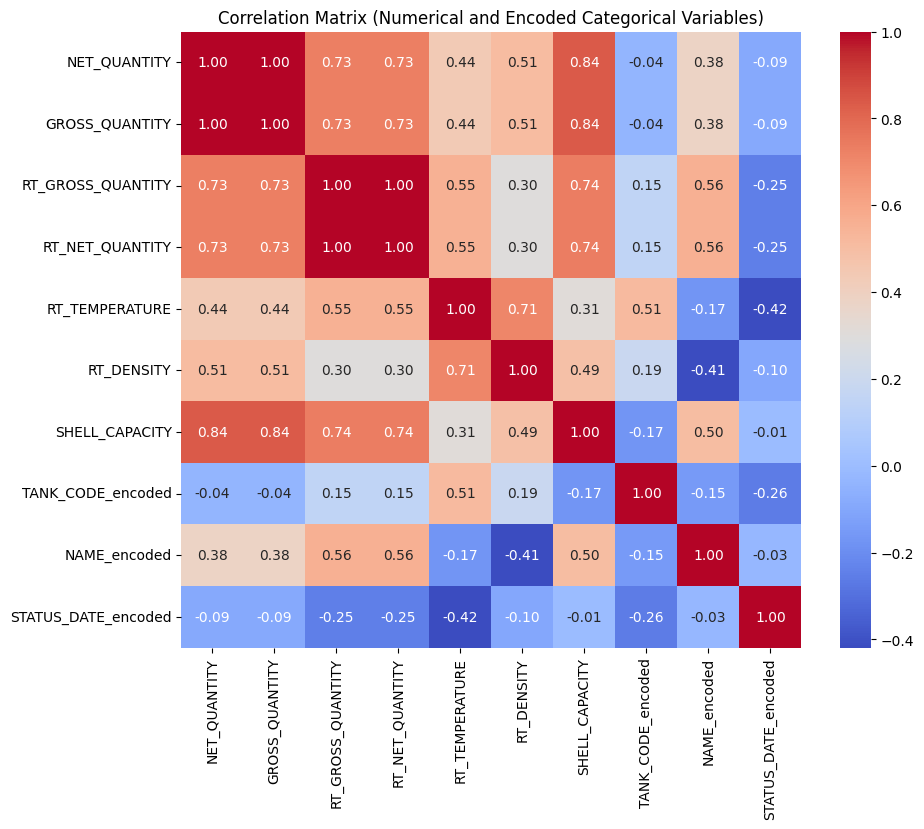

In [38]:
# Calculate correlation matrix
correlation_matrix = saf_stock[encoded_and_numerical].corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numerical and Encoded Categorical Variables)')
plt.show()

**Visualization**

Text(0.5, 1.0, 'Scatter Plot of NET_QUANTITY vs GROSS_QUANTITY')

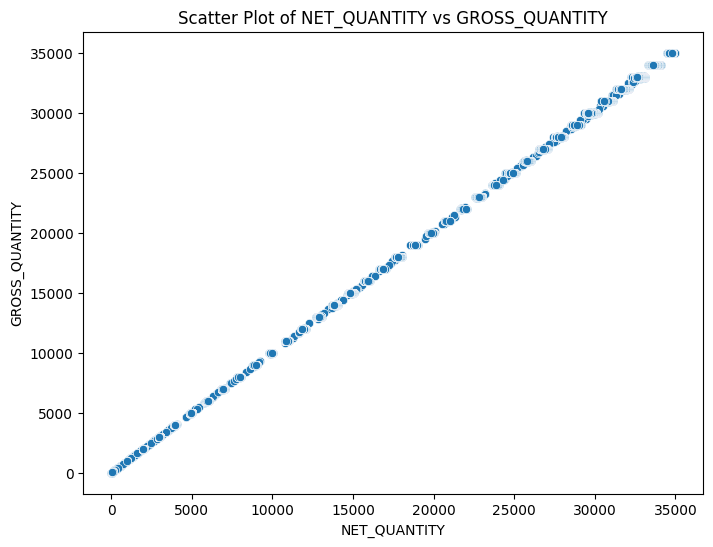

In [39]:
import seaborn as sns

# Define the threshold for high correlation
threshold = 0.7  # Example threshold, you can adjust as needed

# Get correlation between 'NET_QUANTITY' and 'GROSS_QUANTITY'
net_gross_correlation = correlation_matrix.loc['NET_QUANTITY', 'GROSS_QUANTITY']

# Visualize high correlation using scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='NET_QUANTITY', y='GROSS_QUANTITY', data=saf_stock)
plt.title('Scatter Plot of NET_QUANTITY vs GROSS_QUANTITY')



In [40]:
# Calculate correlation between 'NET_QUANTITY' and 'GROSS_QUANTITY'
net_gross_correlation = saf_stock['NET_QUANTITY'].corr(saf_stock['GROSS_QUANTITY'])

print("Correlation between NET_QUANTITY and GROSS_QUANTITY:", net_gross_correlation)


Correlation between NET_QUANTITY and GROSS_QUANTITY: 0.9999832236945193


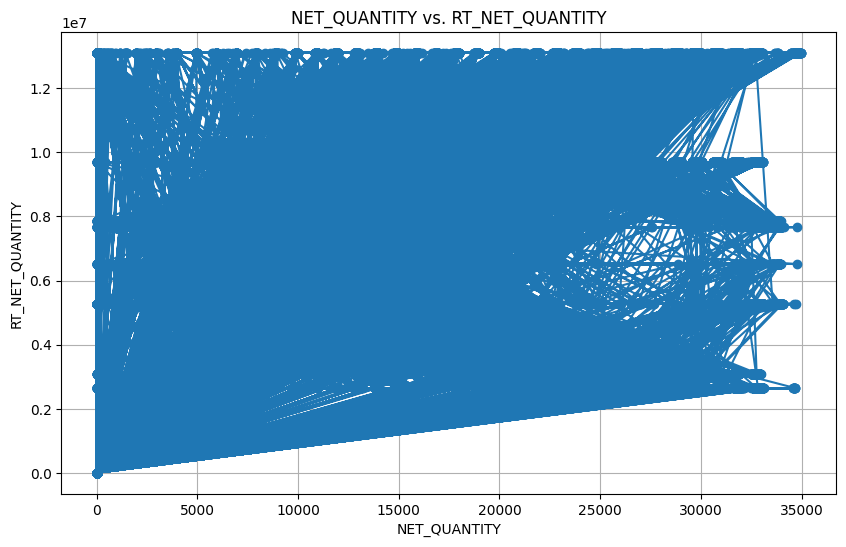

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(saf_stock['NET_QUANTITY'], saf_stock['RT_NET_QUANTITY'], marker='o', linestyle='-')
plt.xlabel('NET_QUANTITY')
plt.ylabel('RT_NET_QUANTITY')
plt.title('NET_QUANTITY vs. RT_NET_QUANTITY')
plt.grid(True)
plt.show()

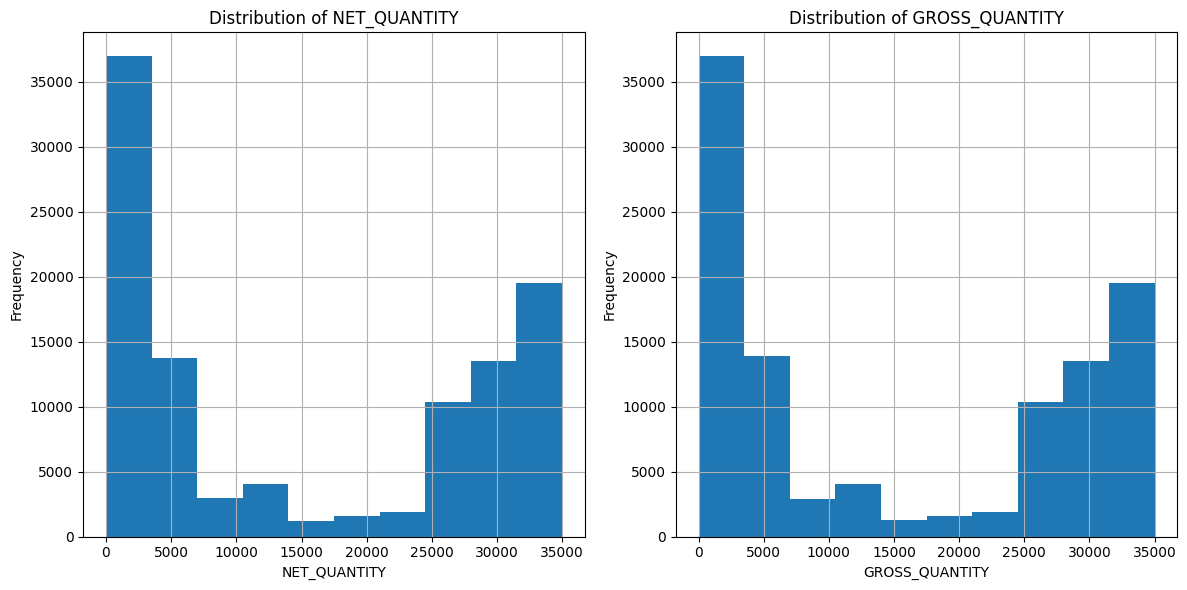

In [42]:
import matplotlib.pyplot as plt

# Set up subplots for histograms
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot histograms for NET_QUANTITY and GROSS_QUANTITY
saf_stock['NET_QUANTITY'].hist(ax=axs[0])
axs[0].set_title('Distribution of NET_QUANTITY')
axs[0].set_xlabel('NET_QUANTITY')
axs[0].set_ylabel('Frequency')

saf_stock['GROSS_QUANTITY'].hist(ax=axs[1])
axs[1].set_title('Distribution of GROSS_QUANTITY')
axs[1].set_xlabel('GROSS_QUANTITY')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


   TANK_CODE  NET_QUANTITY
0     TK-100         24949
1     TK-101      78222360
2     TK-102     105456352
3     TK-104     161546664
4     TK-105      21412425
5     TK-106     161028201
6     TK-200          1470
7     TK-201      19319892
8     TK-202      23395207
9     TK-205    1016045571
10    TK-300         11687
11    TK-400           270
12    TK-500         27634
13    TK-600          5018


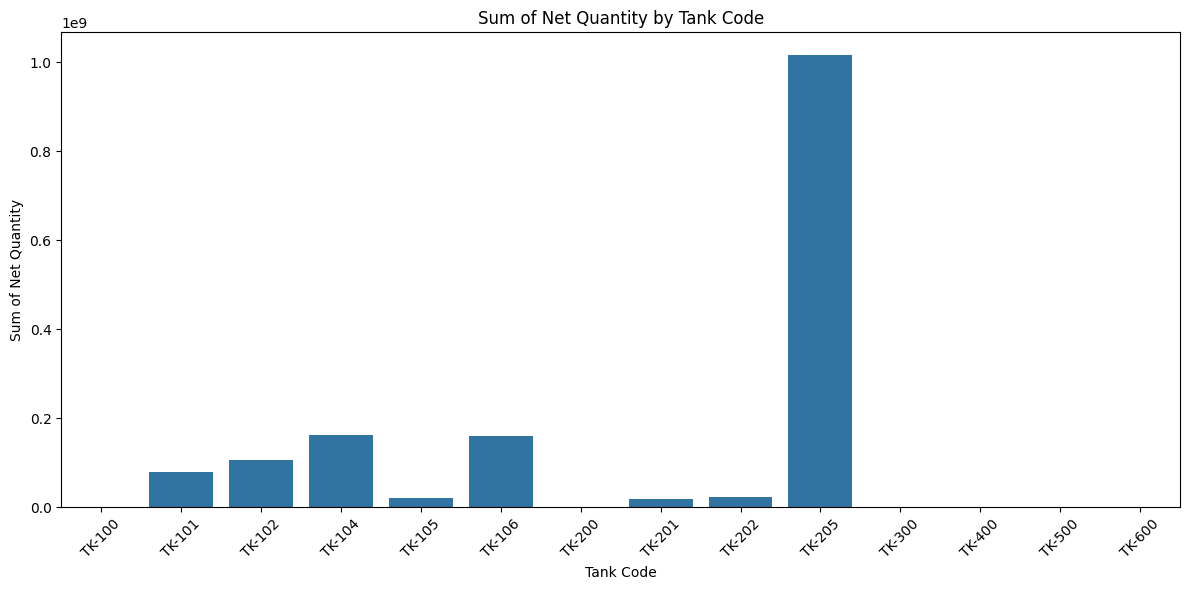

In [43]:
# Group by 'TANK_CODE' and calculate the sum of 'NET_QUANTITY' for each group
net_quantity_sum = saf_stock.groupby('TANK_CODE')['NET_QUANTITY'].sum().reset_index()

print (net_quantity_sum)

# Plot the sum of net quantity by tank code
plt.figure(figsize=(12, 6))
sns.barplot(x='TANK_CODE', y='NET_QUANTITY', data=net_quantity_sum)

# Set titles and labels
plt.title('Sum of Net Quantity by Tank Code')
plt.xlabel('Tank Code')
plt.ylabel('Sum of Net Quantity')

plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()


   TANK_CODE  GROSS_QUANTITY
0     TK-100           24949
1     TK-101        78787786
2     TK-102       105982439
3     TK-104       162329417
4     TK-105        21549312
5     TK-106       162160475
6     TK-200            1470
7     TK-201        19428120
8     TK-202        23558015
9     TK-205      1022476076
10    TK-300           11687
11    TK-400             270
12    TK-500           27634
13    TK-600            5018


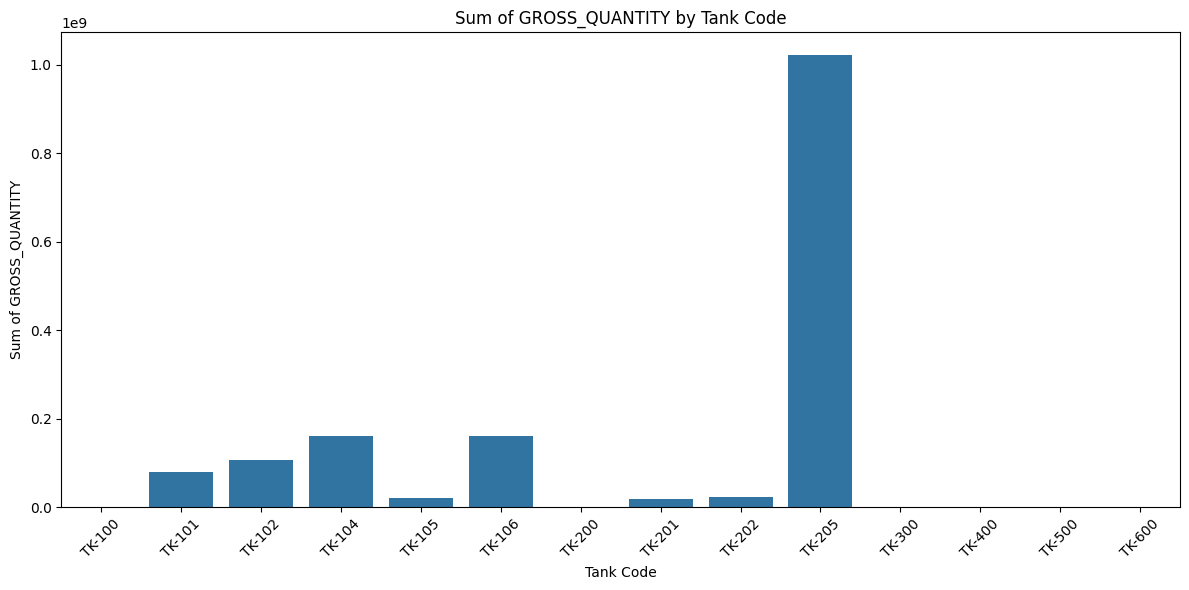

In [44]:
# Group by 'TANK_CODE' and calculate the sum of 'GROSS_QUANTITY' for each group
gross_quantity_sum = saf_stock.groupby('TANK_CODE')['GROSS_QUANTITY'].sum().reset_index()

print (gross_quantity_sum)

# Plot the sum of gross quantity by tank code
plt.figure(figsize=(12, 6))
sns.barplot(x='TANK_CODE', y='GROSS_QUANTITY', data=gross_quantity_sum)

# Set titles and labels
plt.title('Sum of GROSS_QUANTITY by Tank Code')
plt.xlabel('Tank Code')
plt.ylabel('Sum of GROSS_QUANTITY')

plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()


            NAME  NET_QUANTITY
0     ADD GO AFR         24949
1     ADD GO OLA         11687
2   ADD GO TOTAL         27634
3    ADD MOG AFR          1470
4    ADD MOG OLA           270
5  ADD MOG TOTAL          5018
6         GASOIL    1361270947
7          MOGAS     225155725


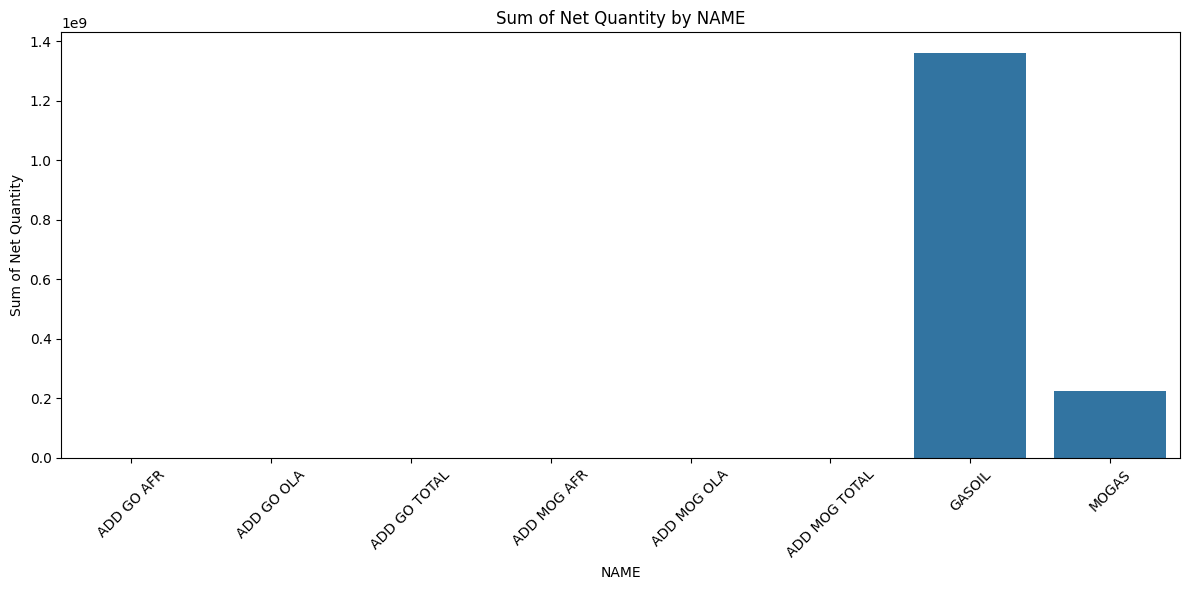

In [45]:
# Group by 'NAME' and calculate the sum of 'NET_QUANTITY' for each group
net_quantity_sum = saf_stock.groupby('NAME')['NET_QUANTITY'].sum().reset_index()

print (net_quantity_sum)

# Plot the sum of net quantity by name
plt.figure(figsize=(12, 6))
sns.barplot(x='NAME', y='NET_QUANTITY', data=net_quantity_sum)

# Set titles and labels
plt.title('Sum of Net Quantity by NAME')
plt.xlabel('NAME')
plt.ylabel('Sum of Net Quantity')

plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()


            NAME  GROSS_QUANTITY
0     ADD GO AFR           24949
1     ADD GO OLA           11687
2   ADD GO TOTAL           27634
3    ADD MOG AFR            1470
4    ADD MOG OLA             270
5  ADD MOG TOTAL            5018
6         GASOIL      1369575718
7          MOGAS       226695922


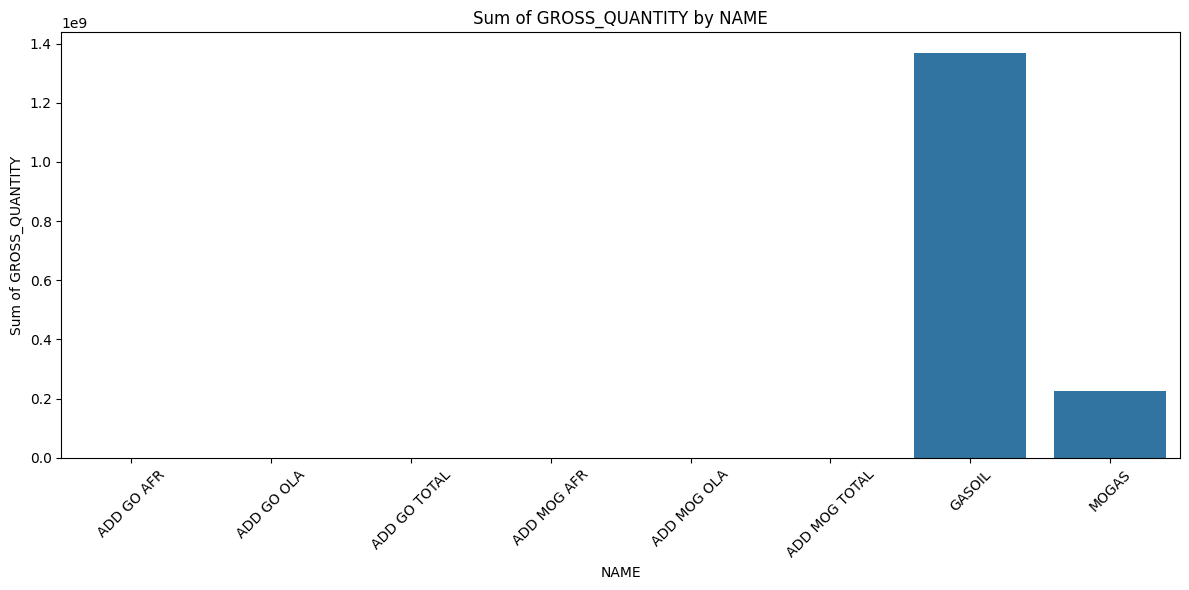

In [46]:
# Group by 'NAME' and calculate the sum of 'GROSS_QUANTITY' for each group
gross_quantity_sum = saf_stock.groupby('NAME')['GROSS_QUANTITY'].sum().reset_index()

print (gross_quantity_sum)

# Plot the sum of gross quantity by name
plt.figure(figsize=(12, 6))
sns.barplot(x='NAME', y='GROSS_QUANTITY', data=gross_quantity_sum)

# Set titles and labels
plt.title('Sum of GROSS_QUANTITY by NAME')
plt.xlabel('NAME')
plt.ylabel('Sum of GROSS_QUANTITY')

plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.tight_layout()
plt.show()


In [47]:

# Group by 'NAME' and calculate the sum of 'NET_QUANTITY' ' for each group
summary = saf_stock.groupby('NAME')['NET_QUANTITY'].sum()

# Print the summary
print(summary)

NAME
ADD GO AFR            24949
ADD GO OLA            11687
ADD GO TOTAL          27634
ADD MOG AFR            1470
ADD MOG OLA             270
ADD MOG TOTAL          5018
GASOIL           1361270947
MOGAS             225155725
Name: NET_QUANTITY, dtype: int64


In [48]:
# Define the order of columns you want in the DataFrame
#desired_columns_order = ['ORDER_ID', 'TANK_CODE', 'NAME', 'NET_QUANTITY', 'RT_NET_QUANTITY', 'GROSS_QUANTITY', 'RT_GROSS_QUANTITY', 'STATUS_DATE', 'RT_TEMPERATURE', 'RT_DENSITY', 'SHELL_CAPACITY']

# Reorder the columns in the DataFrame
#saf_stock = saf_stock[desired_columns_order]

# Define the path where you want to save the new Excel file
#output_file_path = "cleaned_safety_stock.xlsx"

# Save the cleaned dataset with the new column to a new Excel file
#saf_stock.to_excel(output_file_path, index=False)

#print(f"Cleaned dataset saved to {output_file_path}")


**SAFETY COLUMN:**

In [49]:
# Convert STATUS_DATE to datetime if it's not already
saf_stock['STATUS_DATE'] = pd.to_datetime(saf_stock['STATUS_DATE'])

# Sort the dataframe by STATUS_DATE within each order
saf_stock_sorted = saf_stock.sort_values(['ORDER_ID'])

In [50]:
saf_stock_sorted.head()

,ORDER_ID,TANK_CODE,NET_QUANTITY,GROSS_QUANTITY,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,STATUS_DATE,TANK_CODE_encoded,NAME_encoded,STATUS_DATE_encoded
0,8320,TK-205,664,672,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:56:47.440,9,6,2
1,19110,TK-205,21784,21988,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 06:48:58.717,9,6,63
2,19143,TK-205,25750,25989,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 10:09:11.093,9,6,94
3,19143,TK-106,3953,3990,MOGAS,5289004,5273666,17.4,748,9533050,2021-09-28 10:09:11.093,5,7,94
4,19176,TK-205,27733,27994,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:33:14.907,9,6,0


In [51]:
#Group by ORDER_ID and check if STATUS_DATE is different for each group.
for order_id, group in saf_stock_sorted.groupby('ORDER_ID'):
    if len(group['STATUS_DATE'].unique()) > 1:
        print(f"ORDER_ID {order_id} a des STATUS_DATE différents :")
        print(group)


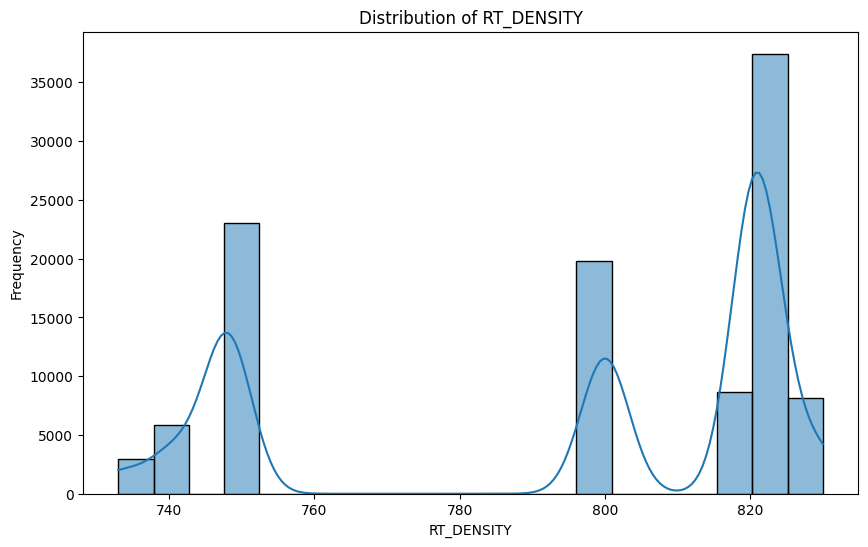

In [52]:
# Calculate summary statistics for density
density_summary = saf_stock_sorted['RT_DENSITY'].describe()

# Visualize the distribution of density values
plt.figure(figsize=(10, 6))
sns.histplot(saf_stock_sorted['RT_DENSITY'], bins=20, kde=True)
plt.title('Distribution of RT_DENSITY')
plt.xlabel('RT_DENSITY')
plt.ylabel('Frequency')
plt.show()




In [53]:
# Calculate min and max density values using percentiles
min_density_value = saf_stock_sorted['RT_DENSITY'].quantile(0.05)  # 5th percentile
max_density_value = saf_stock_sorted['RT_DENSITY'].quantile(0.95)  # 95th percentile

print("Minimum density value (5th percentile):", min_density_value)   # in kg/m^3
print("Maximum density value (95th percentile):", max_density_value)   # in kg/m^3


Minimum density value (5th percentile): 740.0
Maximum density value (95th percentile): 826.0


In [54]:
# Calculate min and max temperature values using percentiles
min_temperature_value = saf_stock_sorted['RT_TEMPERATURE'].quantile(0.05)  # 5th percentile
max_temperature_value = saf_stock_sorted['RT_TEMPERATURE'].quantile(0.95)  # 95th percentile

print("Minimum temperature value (5th percentile):", min_temperature_value)  # in Celsius
print("Maximum temperature value (95th percentile):", max_temperature_value)   # in Celsius


Minimum temperature value (5th percentile): 16.0
Maximum temperature value (95th percentile): 18.9


In [55]:
# Create safety column based on conditions including temperature and density ranges
saf_stock_sorted['SAFETY'] = 1  # Initialize all rows as safe by default
saf_stock_sorted.loc[(saf_stock_sorted['RT_TEMPERATURE'] < min_temperature_value) |
              (saf_stock_sorted['RT_TEMPERATURE'] > max_temperature_value) |
              (saf_stock_sorted['RT_DENSITY'] < min_density_value) |
              (saf_stock_sorted['RT_DENSITY'] > max_density_value) |
              (saf_stock_sorted['NET_QUANTITY'] > saf_stock_sorted['SHELL_CAPACITY']) |
              (saf_stock_sorted['GROSS_QUANTITY'] > saf_stock_sorted['SHELL_CAPACITY']) |
               (saf_stock_sorted['RT_NET_QUANTITY'] > saf_stock_sorted['SHELL_CAPACITY']) |
              (saf_stock_sorted['RT_GROSS_QUANTITY'] > saf_stock_sorted['SHELL_CAPACITY']) |
              (saf_stock_sorted['NET_QUANTITY'] < 0) |
              (saf_stock_sorted['GROSS_QUANTITY'] < 0) |
              (saf_stock_sorted['RT_GROSS_QUANTITY'] < 0) |
              (saf_stock_sorted['RT_NET_QUANTITY'] < 0),
              'SAFETY'] = 0


In [56]:
# Display a sample of the DataFrame with the 'SAFETY' column
saf_stock_sorted.head(15)


,ORDER_ID,TANK_CODE,NET_QUANTITY,GROSS_QUANTITY,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,STATUS_DATE,TANK_CODE_encoded,NAME_encoded,STATUS_DATE_encoded,SAFETY
0,8320,TK-205,664,672,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:56:47.440,9,6,2,1
1,19110,TK-205,21784,21988,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 06:48:58.717,9,6,63,1
2,19143,TK-205,25750,25989,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 10:09:11.093,9,6,94,1
3,19143,TK-106,3953,3990,MOGAS,5289004,5273666,17.4,748,9533050,2021-09-28 10:09:11.093,5,7,94,1
4,19176,TK-205,27733,27994,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:33:14.907,9,6,0,1
5,19209,TK-205,29705,29987,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 10:08:05.390,9,6,93,1
6,19209,TK-500,3,3,ADD GO TOTAL,2500,2493,18.0,800,5000,2021-09-28 10:08:05.390,12,2,93,1
10,19265,TK-600,1,1,ADD MOG TOTAL,2500,2493,18.0,800,5000,2021-09-27 12:44:56.413,13,5,1,1
9,19265,TK-500,2,2,ADD GO TOTAL,2500,2493,18.0,800,5000,2021-09-27 12:44:56.413,12,2,1,1
7,19265,TK-205,27730,27993,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:44:56.413,9,6,1,1


In [57]:
# Sélectionner les lignes où la valeur de température est inférieure à min_temperature_value
selected_rows_for_test = saf_stock_sorted[saf_stock_sorted['RT_TEMPERATURE'] < min_temperature_value]

# Afficher les lignes sélectionnées
print(selected_rows_for_test)


        ORDER_ID TANK_CODE  NET_QUANTITY  GROSS_QUANTITY   NAME  \
108218   1871733    TK-201          5978            5998  MOGAS   
108220   1871773    TK-201          7963            7992  MOGAS   
108222   1871833    TK-201          6968            6992  MOGAS   
108225   1871928    TK-201          7966            7995  MOGAS   
108227   1871975    TK-201          2987            2997  MOGAS   
...          ...       ...           ...             ...    ...   
90125    2709798    TK-201          7890            7991  MOGAS   
111604   2710178    TK-201          3948            3999  MOGAS   
86391    2710269    TK-201          2953            2993  MOGAS   
111606   2710353    TK-201          7881            7995  MOGAS   
111608   2710578    TK-201          1964            1992  MOGAS   

        RT_GROSS_QUANTITY  RT_NET_QUANTITY  RT_TEMPERATURE  RT_DENSITY  \
108218            7856289          7847647            15.9         741   
108220            7856289          7847647     

In [58]:
saf_stock_sorted.shape

(105949, 15)

In [59]:
# Filter the DataFrame to get the row with ORDER_ID 108218
row_1871928 = saf_stock_sorted[saf_stock_sorted['ORDER_ID'] == 1871928]

# Display the row
print(row_1871928)


        ORDER_ID TANK_CODE  NET_QUANTITY  GROSS_QUANTITY    NAME  \
108225   1871928    TK-201          7966            7995   MOGAS   
108224   1871928    TK-101         23836           23981  GASOIL   

        RT_GROSS_QUANTITY  RT_NET_QUANTITY  RT_TEMPERATURE  RT_DENSITY  \
108225            7856289          7847647            15.9         741   
108224            3082788          3076743            17.6         820   

        SHELL_CAPACITY             STATUS_DATE  TANK_CODE_encoded  \
108225        14380470 2022-11-10 03:20:24.787                  7   
108224        40051040 2022-11-10 03:20:24.787                  1   

        NAME_encoded  STATUS_DATE_encoded  SAFETY  
108225             7                40071       0  
108224             6                40071       1  


In [60]:
# Group by TANK_CODE and NAME and count the occurrences of each safety level
safety_by_tank = saf_stock_sorted.groupby(['TANK_CODE', 'SAFETY']).size().unstack(fill_value=0)
safety_by_name = saf_stock_sorted.groupby(['NAME', 'SAFETY']).size().unstack(fill_value=0)




<Figure size 1200x600 with 0 Axes>

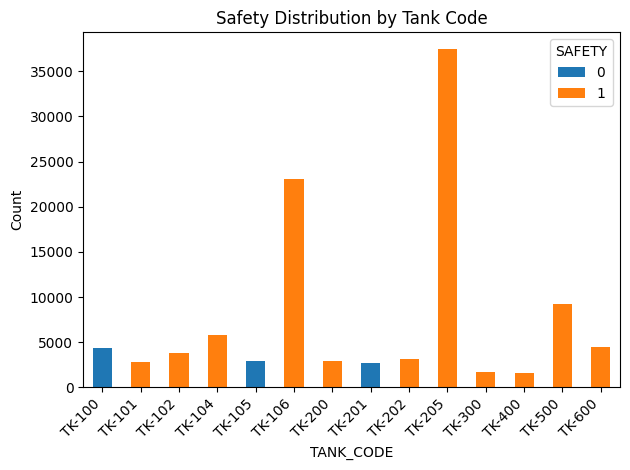

In [61]:
# Plot grouped bar chart for Safety Distribution by Tank Code
plt.figure(figsize=(12, 6))
safety_by_tank.plot(kind='bar', stacked=True)
plt.title('Safety Distribution by Tank Code')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

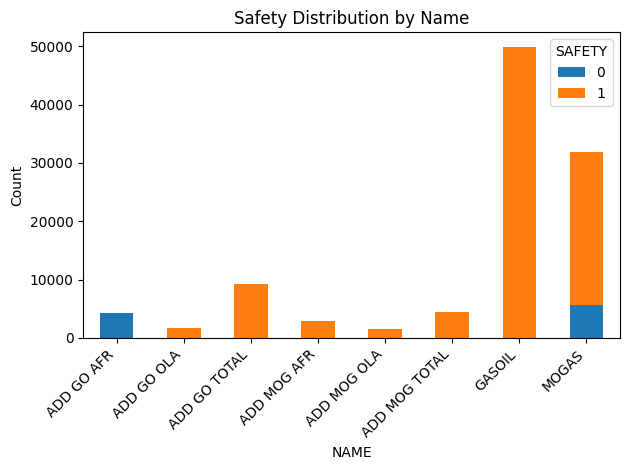

In [62]:
# Plot grouped bar chart for Safety Distribution by Name
plt.figure(figsize=(12, 6))
safety_by_name.plot(kind='bar', stacked=True)
plt.title('Safety Distribution by Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Export Cleaned Dataset**

In [63]:
# Drop the encoded columns from the DataFrame
data_cleaned= saf_stock_sorted.drop(['TANK_CODE_encoded', 'NAME_encoded'], axis=1)

In [64]:
data_cleaned.head()

,ORDER_ID,TANK_CODE,NET_QUANTITY,GROSS_QUANTITY,NAME,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,STATUS_DATE,STATUS_DATE_encoded,SAFETY
0,8320,TK-205,664,672,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:56:47.440,2,1
1,19110,TK-205,21784,21988,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 06:48:58.717,63,1
2,19143,TK-205,25750,25989,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-28 10:09:11.093,94,1
3,19143,TK-106,3953,3990,MOGAS,5289004,5273666,17.4,748,9533050,2021-09-28 10:09:11.093,94,1
4,19176,TK-205,27733,27994,GASOIL,13154914,13110054,18.9,821,27036170,2021-09-27 12:33:14.907,0,1


In [65]:
# Filter the DataFrame to get the row with ORDER_ID 108218
row_108218 = data_cleaned[data_cleaned['ORDER_ID'] == 108218]

# Display the row
print(row_108218)


      ORDER_ID TANK_CODE  NET_QUANTITY  GROSS_QUANTITY    NAME  \
3376    108218    TK-205         32694           32983  GASOIL   

      RT_GROSS_QUANTITY  RT_NET_QUANTITY  RT_TEMPERATURE  RT_DENSITY  \
3376           13154914         13110054            18.9         821   

      SHELL_CAPACITY             STATUS_DATE  STATUS_DATE_encoded  SAFETY  
3376        27036170 2021-10-15 10:47:38.627                 1827       1  


In [66]:
# Define the path where you want to save the new Excel file
path_for_normal = "safety_stock.xlsx"

# Save the cleaned dataset with the new column to a new Excel file
data_cleaned.to_excel(path_for_normal, index=False)

print(f"Cleaned dataset saved to {path_for_normal}")


Cleaned dataset saved to safety_stock.xlsx


In [67]:
# Drop the non-encoded columns from the DataFrame
data_cleaned2= saf_stock_sorted.drop(['TANK_CODE', 'NAME'], axis=1)

In [68]:
data_cleaned2.head()

,ORDER_ID,NET_QUANTITY,GROSS_QUANTITY,RT_GROSS_QUANTITY,RT_NET_QUANTITY,RT_TEMPERATURE,RT_DENSITY,SHELL_CAPACITY,STATUS_DATE,TANK_CODE_encoded,NAME_encoded,STATUS_DATE_encoded,SAFETY
0,8320,664,672,13154914,13110054,18.9,821,27036170,2021-09-27 12:56:47.440,9,6,2,1
1,19110,21784,21988,13154914,13110054,18.9,821,27036170,2021-09-28 06:48:58.717,9,6,63,1
2,19143,25750,25989,13154914,13110054,18.9,821,27036170,2021-09-28 10:09:11.093,9,6,94,1
3,19143,3953,3990,5289004,5273666,17.4,748,9533050,2021-09-28 10:09:11.093,5,7,94,1
4,19176,27733,27994,13154914,13110054,18.9,821,27036170,2021-09-27 12:33:14.907,9,6,0,1


In [69]:
# Define the path where you want to save the new Excel file
path_for_encoded = "safety_stock_encoded.xlsx"

# Save the cleaned dataset with the new column to a new Excel file
data_cleaned2.to_excel(path_for_encoded, index=False)

print(f"Cleaned dataset saved to {path_for_encoded}")


Cleaned dataset saved to safety_stock_encoded.xlsx


### **Model Development:**

### **Conclusion :**

The developed forecasting system for safety stock management in the oil and gas industry aims to improve inventory planning, enhance supply chain resilience, and optimize operational efficiency. By leveraging historical data, advanced analytics, and predictive modeling techniques, the system provides actionable insights for proactive inventory management and risk mitigation.